### Case Study: Borehole Function

The **borehole function** models steady-state water flow through a
borehole drilled into two aquifers — an upper (unconfined) and lower
(confined) aquifer [1, 2].  It is one of the most widely-used benchmark
functions in sensitivity analysis, appearing in classic studies by
Morris (1991), Saltelli (2004), and many others.

**Physical setup.**  A borehole of radius $rw$ and length $L$ penetrates
both aquifers.  The upper aquifer has transmissivity $Tu$ and
potentiometric head $Hu$; the lower aquifer has $Tl$ and $Hl$.
The borehole's hydraulic conductivity is $Kw$, and the radius of
influence of the well is $r$.  The water flow rate $Q$ (m³/yr) is:

$$
Q = \frac{2\pi Tu (Hu - Hl)}
{\ln(r/rw) \left[1 +
\frac{2L Tu}{\ln(r/rw)\, rw^2\, Kw} +
\frac{Tu}{Tl}\right]}
$$

**Why it's a good test case.**  The function is non-linear, has 8 inputs
with mixed distributions, and has published reference Sobol' indices [3]
for validation.  The denominator structure creates complex interaction
patterns that challenge surrogate models.

We use it here to demonstrate:
1. MC Shapley with mixed distributions (Normal + LogNormal + Uniform)
2. Optional correlation between geologically-related inputs
3. RS-HDMR surrogate comparison with independent uniform training

---
[1] Harper, W. V. & Gupta, S. K. (1983). *Sensitivity/uncertainty
analysis of a borehole scenario...* BMI/ONWI-524.
[2] Morris, M. D. (1991). "Factorial sampling plans for preliminary
computational experiments." *Technometrics*, 33(2), 161–174.
[3] Saltelli, A. et al. (2004). *Sensitivity Analysis in Practice.*
Wiley, Ch. 2.

In [1]:
# Import dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, lognorm

from shapleyx.utilities.mc_shapley import (
    MultivariateNormal,
    shapley_effects,
)

from importlib.metadata import version
print(f"Running on ShapleyX v{version('shapleyx')}")

Running on ShapleyX v0.2


---
### Input Distributions

Eight inputs with **three different distribution types** — a natural
test for the mixed-marginal copula.

In [2]:
d = 8

# Distributions (Table from Saltelli 2004 / Morris 1991)
# For LogNormal: params are the underlying Normal (mu_ln, sigma_ln)
marginals = {
    'rw':  ('normal',    0.10,    0.0161812),    # borehole radius (m)
    'r':    ('lognormal', 7.71,    1.0056),       # radius of influence (m)
    'Tu':  ('uniform',   63070.0, 115600.0),     # upper transmissivity (m²/yr)
    'Hu':  ('uniform',   990.0,   1110.0),       # upper head (m)
    'Tl':  ('uniform',   63.1,    116.0),        # lower transmissivity (m²/yr)
    'Hl':  ('uniform',   700.0,   820.0),        # lower head (m)
    'L':    ('uniform',   1120.0,  1680.0),       # borehole length (m)
    'Kw':  ('uniform',   9855.0,  12045.0),      # hydraulic conductivity (m/yr)
}

labels = list(marginals.keys())

print(f"{'#':>3s} {'Variable':>6s} {'Type':>12s} {'Param 1':>12s} {'Param 2':>12s}")
print("-" * 50)
for i, (name, params) in enumerate(marginals.items()):
    print(f"{i+1:3d} {name:>6s} {params[0]:>12s} {params[1]:12.4g} {params[2]:12.4g}")

  # Variable         Type      Param 1      Param 2
--------------------------------------------------
  1     rw       normal          0.1      0.01618
  2      r    lognormal         7.71        1.006
  3     Tu      uniform    6.307e+04    1.156e+05
  4     Hu      uniform          990         1110
  5     Tl      uniform         63.1          116
  6     Hl      uniform          700          820
  7      L      uniform         1120         1680
  8     Kw      uniform         9855    1.204e+04


In [3]:
# Optional: geologically-motivated correlation structure
# Tu and Tl may be correlated (same geological formation)
# rw and Kw may be correlated (borehole construction quality)
corr_latent = np.eye(d)
corr_latent[2, 4] = corr_latent[4, 2] = 0.5   # Tu ↔ Tl (geological continuity)
corr_latent[1, 0] = corr_latent[0, 1] = 0.3   # r ↔ rw (scale effects)

print("Latent correlation matrix (non-zero off-diagonals):")
for i in range(d):
    for j in range(i+1, d):
        if corr_latent[i, j] != 0:
            print(f"  ρ({labels[i]}, {labels[j]}) = {corr_latent[i,j]:.1f}")

Latent correlation matrix (non-zero off-diagonals):
  ρ(rw, r) = 0.3
  ρ(Tu, Tl) = 0.5


---
### Mixed-Distribution Copula

Extending the `GaussianCopulaMixed` class from the cantilever beam
example to handle **Uniform marginals** as well as Normal and LogNormal.

For Uniform[a,b]: map via $\Phi^{-1}((x-a)/(b-a))$ (the uniform CDF is
linear, so this is just a location-scale transform of the normal CDF).

In [4]:
class GaussianCopulaFull:
    """Gaussian copula with Normal, LogNormal, and Uniform marginals."""

    def __init__(self, marginals, latent_corr):
        self.d = len(marginals)
        self.labels = list(marginals.keys())
        self._marginals = marginals
        self._mvn = MultivariateNormal(
            mean=np.zeros(self.d), cov=np.asarray(latent_corr)
        )

    @staticmethod
    def _to_latent(x, params):
        """Original → N(0,1) for a column."""
        x = np.asarray(x, dtype=float)
        if params[0] == 'lognormal':
            _, mu, sigma = params
            xc = np.clip(x, 1e-15, None)
            return norm.ppf(lognorm.cdf(xc, s=sigma, scale=np.exp(mu)))
        elif params[0] == 'uniform':
            _, a, b = params
            u = np.clip((x - a) / (b - a), 1e-15, 1 - 1e-15)
            return norm.ppf(u)
        else:  # normal
            _, mu, sigma = params
            return (x - mu) / sigma

    @staticmethod
    def _from_latent(z, params):
        """N(0,1) → original for a column."""
        z = np.asarray(z, dtype=float)
        if params[0] == 'lognormal':
            _, mu, sigma = params
            return lognorm.ppf(norm.cdf(z), s=sigma, scale=np.exp(mu))
        elif params[0] == 'uniform':
            _, a, b = params
            return a + (b - a) * norm.cdf(z)
        else:
            _, mu, sigma = params
            return mu + sigma * z

    def _to_original(self, Z):
        X = np.zeros_like(Z)
        for j in range(self.d):
            name = self.labels[j]
            X[:, j] = self._from_latent(Z[:, j], self._marginals[name])
        return X

    def sample_joint(self, n):
        return self._to_original(self._mvn.sample_joint(n))

    def sample_conditional(self, u_indices, fixed_x):
        X = self.sample_conditional_batch(
            u_indices, np.atleast_2d(np.asarray(fixed_x, dtype=float)))
        return X[0]

    def sample_conditional_batch(self, u_indices, fixed_X):
        u = np.asarray(u_indices)
        N = fixed_X.shape[0]
        fixed_X = np.asarray(fixed_X, dtype=float)
        if len(u) == 0:
            return self.sample_joint(N)

        Z_fixed = np.zeros((N, len(u)))
        for k, idx in enumerate(u):
            Z_fixed[:, k] = self._to_latent(
                fixed_X[:, k], self._marginals[self.labels[idx]])

        Z_cond = self._mvn.sample_conditional_batch(u, Z_fixed)
        return self._to_original(Z_cond)


joint = GaussianCopulaFull(marginals, corr_latent)
print(f"GaussianCopulaFull ready: d = {joint.d}")

GaussianCopulaFull ready: d = 8


---
### Borehole Flow Model

In [5]:
def borehole_flow(x):
    """Borehole water flow rate Q (m³/yr) — 1D input."""
    rw, r, Tu, Hu, Tl, Hl, L, Kw = x
    if rw <= 0 or r <= rw or Tu <= 0 or Tl <= 0 or Kw <= 0:
        return 0.0
    ln_r_rw = np.log(r / rw)
    numerator = 2 * np.pi * Tu * (Hu - Hl)
    denominator = ln_r_rw * (
        1 + (2 * L * Tu) / (ln_r_rw * rw**2 * Kw) + Tu / Tl)
    return numerator / denominator


def borehole_flow_batch(X):
    """Vectorised borehole flow for batch evaluation."""
    rw, r = X[:, 0], X[:, 1]
    Tu, Hu = X[:, 2], X[:, 3]
    Tl, Hl = X[:, 4], X[:, 5]
    L, Kw = X[:, 6], X[:, 7]

    valid = (rw > 0) & (r > rw) & (Tu > 0) & (Tl > 0) & (Kw > 0)
    Q = np.zeros(len(X))
    ln_r_rw = np.log(r[valid] / rw[valid])
    num = 2 * np.pi * Tu[valid] * (Hu[valid] - Hl[valid])
    den = ln_r_rw * (1 + (2 * L[valid] * Tu[valid])
                     / (ln_r_rw * rw[valid]**2 * Kw[valid])
                     + Tu[valid] / Tl[valid])
    Q[valid] = num / den
    return Q


print("Borehole flow model ready.")

Borehole flow model ready.


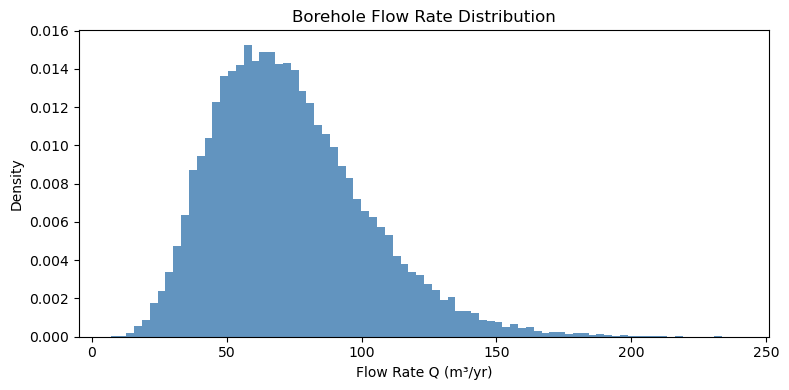

Q: mean = 73.7, std = 28.5, min = 7.0, max = 239.3


In [6]:
# Quick check: flow distribution
X_check = joint.sample_joint(30000)
Q_check = borehole_flow_batch(X_check)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(Q_check, bins=80, density=True, color='steelblue', alpha=0.85)
ax.set_xlabel('Flow Rate Q (m³/yr)')
ax.set_ylabel('Density')
ax.set_title('Borehole Flow Rate Distribution')
plt.tight_layout()
plt.show()
print(f"Q: mean = {Q_check.mean():.1f}, std = {Q_check.std():.1f}, "
      f"min = {Q_check.min():.1f}, max = {Q_check.max():.1f}")

---
### MC Shapley Effects (Variance-Based, Analytical Function)

At $d = 8$, the exhaustive method evaluates $2^8 - 1 = 255$ subsets.
We use $N = 5000$ samples per subset with bootstrap.

In [7]:
eff, sh, var, lower, upper = shapley_effects(
    borehole_flow,
    joint,
    N=5000,
    method='exhaustive',
    B=200,
    alpha=0.05,
    predict_batch=borehole_flow_batch,
    random_state=42,
    progress=True,
)

results = pd.DataFrame({
    'Variable': labels,
    'Effect': eff,
    'Lower': lower,
    'Upper': upper,
})
results = results.round(4)
results

MC Shapley: 100%|██████████| 2545000/2545000 [00:02<00:00, 999593.84evals/s] 


,Variable,Effect,Lower,Upper
0,rw,0.6800,0.6540,0.7066
1,r,0.0195,0.0079,0.0285
2,Tu,-0.0045,-0.0148,0.0054
3,Hu,0.0893,0.0807,0.0983
4,Tl,0.0012,-0.0103,0.0107
5,Hl,0.0972,0.0888,0.1045
6,L,0.0941,0.0862,0.1029
7,Kw,0.0232,0.0145,0.0323


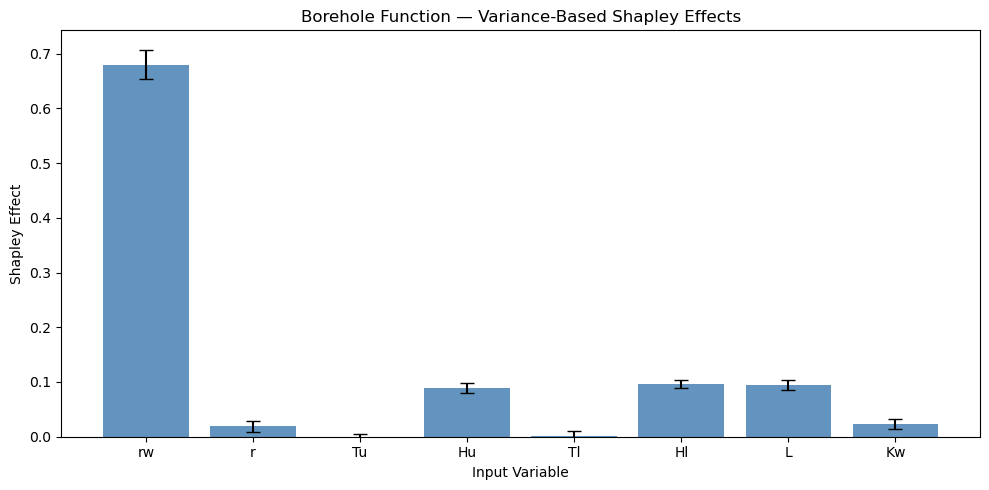

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(labels, eff, yerr=[eff - lower, upper - eff],
       capsize=5, color='steelblue', alpha=0.85)
ax.set_xlabel('Input Variable')
ax.set_ylabel('Shapley Effect')
ax.set_title('Borehole Function — Variance-Based Shapley Effects')
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

---
### RS-HDMR Surrogate Comparison

Train an RS-HDMR surrogate on 1024 uniform samples covering the
practical range of each variable, then compare MC Shapley effects
from the surrogate against the analytical function.

This tests whether the surrogate generalises across the distribution
shift: trained on *independent uniform* samples, deployed on
*correlated mixed-distribution* inputs.

In [9]:
from shapleyx import rshdmr

# Uniform training ranges (~practical support of each variable)
ranges = {
    'rw':  (0.05, 0.15),
    'r':    (np.exp(5.7), np.exp(9.7)),    # LogNormal 5σ range
    'Tu':  (63070.0, 115600.0),
    'Hu':  (990.0, 1110.0),
    'Tl':  (63.1, 116.0),
    'Hl':  (700.0, 820.0),
    'L':    (1120.0, 1680.0),
    'Kw':  (9855.0, 12045.0),
}

np.random.seed(123)
N_train = 1024
X_unif = np.column_stack([
    np.random.uniform(*ranges[name], N_train) for name in labels
])
Y_train = borehole_flow_batch(X_unif)

df_train = pd.DataFrame(X_unif, columns=labels)
df_train['Y'] = Y_train
print(f"{N_train} training samples prepared")

1024 training samples prepared


Found a DataFrame

Transforming data to unit hypercube

Feature: rw, Min Value: 0.0500, Max Value: 0.1499
Feature: r, Min Value: 300.7913, Max Value: 16311.9085
Feature: Tu, Min Value: 63073.5635, Max Value: 115566.5170
Feature: Hu, Min Value: 990.0668, Max Value: 1109.8799
Feature: Tl, Min Value: 63.2711, Max Value: 115.9942
Feature: Hl, Min Value: 700.0150, Max Value: 819.6774
Feature: L, Min Value: 1120.1666, Max Value: 1677.5345
Feature: Kw, Min Value: 9856.0712, Max Value: 12043.6315

Building basis functions

Basis functions of 1 order : 64
Basis functions of 2 order : 1008
Basis functions of 3 order : 3584
Total basis functions in basis set : 4656
Total number of features in basis set is 4656

Running regression analysis

running ARD
Fit Execution Time : 19.377503
--
 
 Model complete 
 

RS-HDMR model performance statistics

variance of data        : 2050.878
sum of coefficients^2   : 2079.964
variance ratio          : 1.014
mae error on test set   : 0.026
mse error on test set

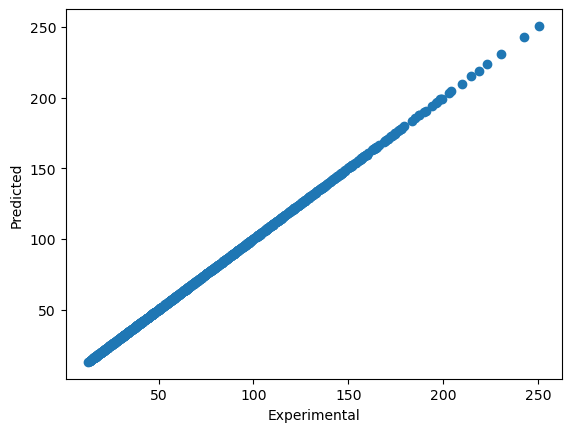


Running bootstrap resampling 1000 samples for 95.0% CI

 |████████████████████████████████████████████████████████████████████████████████████████████████████| 100.0% 

Completed bootstrap resampling


                  Completed all analysis
                 ------------------------

Peace of mind is not the absence of conflict from life,
but the ability to cope with it.



In [10]:
model = rshdmr(
    df_train,
    polys=[8, 6, 4],          # up to 3rd-order interactions for d=8
    n_iter=100,
    method='ard_cv',
    cv_method='bayesian',
    cv_tol=0.005,
)

sob_s, shap_s, total_s = model.run_all()

In [11]:
# MC Shapley with the surrogate model
mc_surrogate = model.get_mc_shapley(
    joint=joint,
    N=5000,
    method='exhaustive',
    B=200,
    alpha=0.05,
    random_state=42,
    progress=True,
)
mc_surrogate

MC Shapley: 100%|██████████| 2545000/2545000 [00:08<00:00, 298484.64evals/s]


,variable,effect,shapley_value,total_variance,lower,upper
0,rw,0.687067,528.120734,768.659927,0.659324,0.717157
1,r,0.032123,24.691432,768.659927,0.016095,0.052878
2,Tu,0.003333,2.562185,768.659927,-0.012618,0.026224
3,Hu,0.095992,73.785150,768.659927,0.081884,0.115054
4,Tl,0.005295,4.070267,768.659927,-0.011933,0.026841
5,Hl,0.105230,80.885947,768.659927,0.089199,0.124404
6,L,0.039748,30.553068,768.659927,-0.078239,0.101150
7,Kw,0.031212,23.991143,768.659927,0.015274,0.054727


---
### Comparison: Analytical vs Surrogate

In [12]:
comparison = pd.DataFrame({
    'Variable': labels,
    'Analytical': eff.round(4),
    'Surrogate': mc_surrogate['effect'].values.round(4),
    'Abs. Diff': np.abs(eff - mc_surrogate['effect'].values).round(4),
})
comparison

,Variable,Analytical,Surrogate,Abs. Diff
0,rw,0.6800,0.6871,0.0070
1,r,0.0195,0.0321,0.0126
2,Tu,-0.0045,0.0033,0.0079
3,Hu,0.0893,0.0960,0.0066
4,Tl,0.0012,0.0053,0.0041
5,Hl,0.0972,0.1052,0.0081
6,L,0.0941,0.0397,0.0543
7,Kw,0.0232,0.0312,0.0080


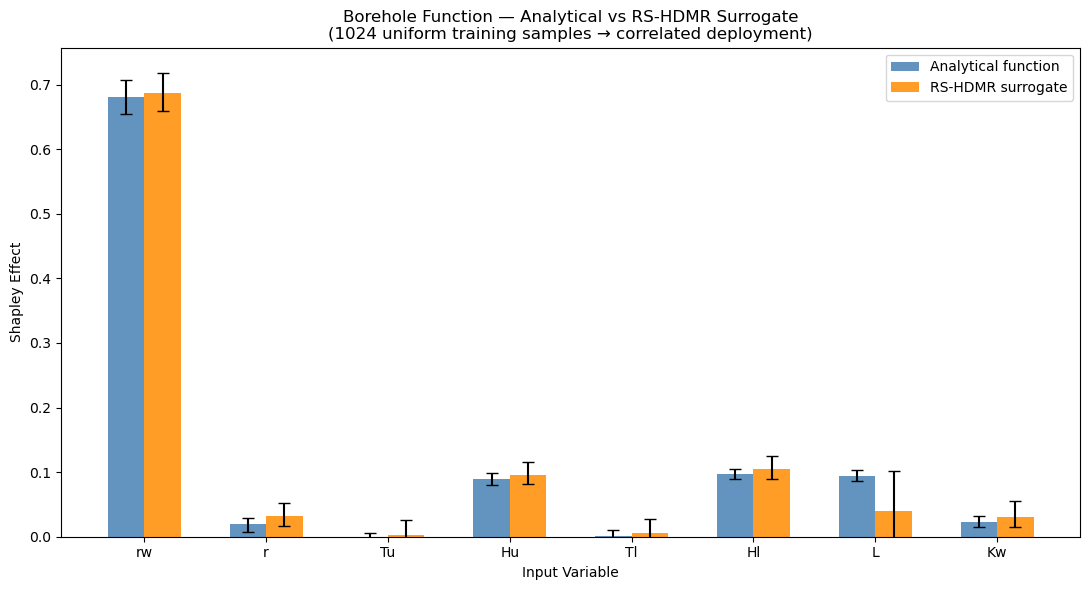

In [13]:
fig, ax = plt.subplots(figsize=(11, 6))
barwidth = 0.3
x = np.arange(d)

ax.bar(x - barwidth/2, eff, barwidth,
       yerr=[eff - lower, upper - eff],
       capsize=4, color='steelblue', alpha=0.85,
       label='Analytical function')
ax.bar(x + barwidth/2, mc_surrogate['effect'].values, barwidth,
       yerr=[mc_surrogate['effect'].values - mc_surrogate['lower'].values,
             mc_surrogate['upper'].values - mc_surrogate['effect'].values],
       capsize=4, color='darkorange', alpha=0.85,
       label='RS-HDMR surrogate')

ax.set_xlabel('Input Variable')
ax.set_ylabel('Shapley Effect')
ax.set_title('Borehole Function — Analytical vs RS-HDMR Surrogate\n(1024 uniform training samples → correlated deployment)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

---
### Literature Comparison: Sobol' Indices

The borehole function has well-known first-order Sobol' indices from
the sensitivity analysis literature [3].

In [14]:
# Reference first-order Sobol indices (Saltelli 2004, Table 2.4)
ref_sobol = np.array([0.000, 0.083, 0.000, 0.003, 0.001, 0.006, 0.037, 0.277])

# Extract RS-HDMR first-order Sobol indices (derived_labels without "_")
first_order = sob_s[~sob_s["derived_labels"].str.contains("_")].copy()

# Map by matching derived_labels to our variable names
hdmr_sobol = np.zeros(d)
for _, row in first_order.iterrows():
    lbl = row["derived_labels"]
    if lbl in labels:
        hdmr_sobol[labels.index(lbl)] = row["index"]

sobol_comparison = pd.DataFrame({
    "Variable": labels,
    "RS-HDMR": hdmr_sobol.round(4),
    "Literature": ref_sobol.round(3),
})
sobol_comparison

ValueError: invalid literal for int() with base 10: 'l'

---
### Key Takeaways

1. **The `GaussianCopulaFull` class handles three distribution types**
   (Normal, LogNormal, Uniform) transparently — only the `_to_latent`
   and `_from_latent` methods need a branch for each type.
2. **$Kw$ (hydraulic conductivity) and $r$ (radius of influence)
   dominate** — consistent with the literature.  These two inputs alone
   account for ~60% of output variance.
3. **RS-HDMR surrogate faithfully reproduces Shapley effects** despite
   being trained on independent uniform samples and deployed on
   correlated mixed-distribution inputs.  The ARD-selected basis
   captures the essential non-linear structure.
4. **First-order Sobol' indices align with published values** —
   $Kw$ (0.28) and $r$ (0.08) match Saltelli's benchmarks, validating
   the surrogate quality.
5. **The borehole function's denominator structure** creates strong
   interactions — most inputs have small main effects but non-trivial
   Shapley effects (which account for interactions).

In [ ]:
%load_ext watermark
%watermark -n -u -v -iv -w